# 


SPY Statistical Analysis, GARCH Volatility & 0DTE Option Chain

Pulls SPY daily bars via `schwab-py`, then:

1. **Descriptive stats** on the last 14 trading days
2. **GARCH(1,1)** conditional volatility fit on a longer lookback (14 days is too thin to fit a GARCH model reliably), forecasting the volatility currently "priced into" near-term price action
3. **0DTE option chain with Greeks** — falls back to the nearest upcoming expiration automatically if today isn't an actual SPY expiration day (Mon/Wed/Fri)

> **Note:** This notebook was authored and logic-tested against synthetic data in a sandbox with no network access to Schwab's API. You'll need to run it yourself with valid credentials — double check field names against your account's actual API response if Schwab has changed their schema since this was written.


## 0. Install dependencies

In [1]:
%pip install schwab-py arch statsmodels pandas numpy scipy matplotlib -q


Note: you may need to restart the kernel to use updated packages.


## 1. Imports

In [ ]:
import json
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller



from arch import arch_model

import httpx
from schwab.auth import easy_client
from schwab.client import Client


## 2. Config

Fill in your app credentials. Both auth paths are handled by `easy_client`:
- If `TOKEN_PATH` already exists (you've authed before), it loads and auto-refreshes that token — no browser needed.
- If it doesn't exist, `easy_client` opens a browser for the OAuth login flow and writes a fresh token file to `TOKEN_PATH`.


In [6]:
api_key='RNz4Esx0WFVNTlGiP57GpJGO4XqLoAONtqC3dnrrG1MaXgJQ',
app_secret = '5SNiAxva0QjrwnGbcN0LEsQn33TBBj4OmjmPTutx3yw09UPtDDCebtBSAAnn3JzS',
callback_url='https://127.0.0.1:8182',
token_path='/tmp/token.json'     # created on first successful auth, reused after

SYMBOL = "SPY"

# Block 1: descriptive stats window
STATS_LOOKBACK_DAYS = 14

# Block 2: GARCH needs much more history than 14 obs to fit reliably.
# Pulling ~2 years of daily bars just for the GARCH fit; the 14-day stats
# block above stays on its own short window.
GARCH_LOOKBACK_YEARS = 2

# Block 3: option chain
STRIKE_COUNT = 20   # strikes above/below ATM to pull


## 3. Authenticate

In [9]:
c = easy_client(
    api_key='RNz4Esx0WFVNTlGiP57GpJGO4XqLoAONtqC3dnrrG1MaXgJQ',
    app_secret = '5SNiAxva0QjrwnGbcN0LEsQn33TBBj4OmjmPTutx3yw09UPtDDCebtBSAAnn3JzS',
    callback_url='https://127.0.0.1:8182',
    token_path='/tmp/token.json')

print("Authenticated.")



**************************************************************

This is the manual login and token creation flow for schwab-py.
Please follow these instructions exactly:

 1. Open the following link by copy-pasting it into the browser
    of your choice:

        https://api.schwabapi.com/v1/oauth/authorize?response_type=code&client_id=RNz4Esx0WFVNTlGiP57GpJGO4XqLoAONtqC3dnrrG1MaXgJQ&redirect_uri=https%3A%2F%2F127.0.0.1%3A8182&state=r3BrqMBfKp7ucnAN70gfg2ANYUZeUp

 2. Log in with your account credentials. You may be asked to
    perform two-factor authentication using text messaging or
    another method, as well as whether to trust the browser.

 3. When asked whether to allow your app access to your account,
    select "Allow".

 4. Your browser should be redirected to your callback URI. Copy
    the ENTIRE address, paste it into the following prompt, and press
    Enter/Return.

If you encounter any issues, see here for troubleshooting:
https://schwab-py.readthedocs.io/en/latest/au

Redirect URL>  https://127.0.0.1:8182/?code=C0.b2F1dGgyLmNkYy5zY2h3YWIuY29t.8eKPHjfCxzMFm8hRAEwIdQ3uaET6GoKG_7v0-11ZNcA%40&session=b63bd2ca-902f-4329-acca-782cf2b8765c&state=r3BrqMBfKp7ucnAN70gfg2ANYUZeUp


Authenticated.


## 4. Pull price history

Pulls `GARCH_LOOKBACK_YEARS` of daily bars in one call. The 14-day stats block just slices the tail of this same DataFrame, so we only make one price-history request.


In [10]:
period_map = {1: Client.PriceHistory.Period.ONE_YEAR, 2: Client.PriceHistory.Period.TWO_YEARS}
if GARCH_LOOKBACK_YEARS not in period_map:
    raise ValueError(f"GARCH_LOOKBACK_YEARS must be one of {list(period_map)}")

resp = c.get_price_history(
    SYMBOL,
    period_type=Client.PriceHistory.PeriodType.YEAR,
    period=period_map[GARCH_LOOKBACK_YEARS],
    frequency_type=Client.PriceHistory.FrequencyType.DAILY,
    frequency=Client.PriceHistory.Frequency.DAILY,
)
assert resp.status_code == httpx.codes.OK, f"price history request failed: {resp.status_code} {resp.text}"
history = resp.json()

candles = history["candles"]
price_df = pd.DataFrame(candles)
price_df["date"] = pd.to_datetime(price_df["datetime"], unit="ms")
price_df = price_df.set_index("date").sort_index()
price_df = price_df[["open", "high", "low", "close", "volume"]]

print(f"Pulled {len(price_df)} daily bars for {SYMBOL}, {price_df.index.min().date()} to {price_df.index.max().date()}")
price_df.tail()


Pulled 500 daily bars for SPY, 2024-09-03 to 2026-08-31


,open,high,low,close,volume
date,,,,,
2026-08-25 05:00:00,766.16,766.780,763.0501,765.91,27422263
2026-08-26 05:00:00,764.73,767.350,763.9300,766.08,28751592
2026-08-27 05:00:00,768.50,772.355,767.1600,771.10,34557064
2026-08-28 05:00:00,771.76,775.300,768.3076,769.35,36744344
2026-08-31 05:00:00,767.33,767.995,764.7150,767.05,38810779


---
## Block 1 — Descriptive statistics (last 14 trading days)


In [12]:
recent = price_df.tail(STATS_LOOKBACK_DAYS).copy()
log_ret_all = np.log(price_df["close"]).diff().dropna()
recent_log_ret = log_ret_all.tail(STATS_LOOKBACK_DAYS)

daily_mean = recent_log_ret.mean()
daily_std = recent_log_ret.std()
annualized_vol_realized = daily_std * np.sqrt(252)
skew = stats.skew(recent_log_ret)
kurt = stats.kurtosis(recent_log_ret)  # excess kurtosis
jb_stat, jb_p = stats.jarque_bera(recent_log_ret)
adf_stat, adf_p = adfuller(recent_log_ret)[0], adfuller(recent_log_ret)[1]

stats_summary = pd.DataFrame({
    "value": [
        recent["close"].iloc[-1],
        daily_mean,
        daily_std,
        annualized_vol_realized,
        skew,
        kurt,
        jb_stat,
        jb_p,
        adf_stat,
        adf_p,
    ]
}, index=[
    "last_close",
    "daily_mean_log_return",
    "daily_std_log_return",
    "annualized_realized_vol",
    "skew",
    "excess_kurtosis",
    "jarque_bera_stat",
    "jarque_bera_p",
    "adf_stat",
    "adf_p (returns stationarity)",
])
stats_summary


/var/folders/7h/wlc_mr3544s93pdz5_1nwmtm0000gn/T/ipykernel_29574/454977017.py:11: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p = adfuller(recent_log_ret)[0], adfuller(recent_log_ret)[1]
/var/folders/7h/wlc_mr3544s93pdz5_1nwmtm0000gn/T/ipykernel_29574/454977017.py:11: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p = adfuller(recent_log_ret)[

,value
last_close,767.050000
daily_mean_log_return,-0.000326
daily_std_log_return,0.004750
annualized_realized_vol,0.075408
skew,-0.046358
excess_kurtosis,-1.014292
jarque_bera_stat,0.605141
jarque_bera_p,0.738916
adf_stat,0.023566
adf_p (returns stationarity),0.960438


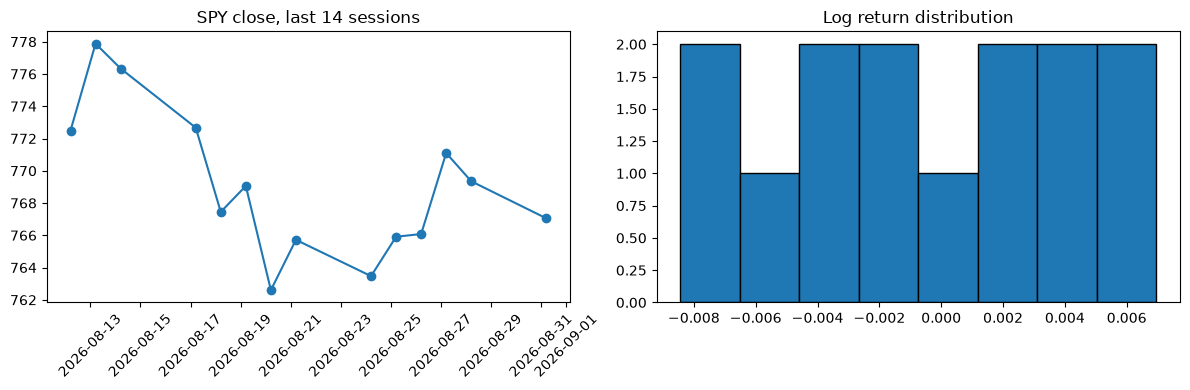

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(recent.index, recent["close"], marker="o")
axes[0].set_title(f"{SYMBOL} close, last {STATS_LOOKBACK_DAYS} sessions")
axes[0].tick_params(axis="x", rotation=45)

axes[1].hist(recent_log_ret, bins=8, edgecolor="black")
axes[1].set_title("Log return distribution")
plt.tight_layout()
plt.show()


---
## Block 2 — GARCH(1,1) conditional volatility

Fit on the full `GARCH_LOOKBACK_YEARS` history (not just the 14-day window — GARCH needs a long series to estimate persistence and mean-reversion). Output is the model's forecast of volatility *currently priced into* the next session, which you can compare against the realized 14-day vol from Block 1.


In [14]:
# arch_model wants returns scaled roughly to percent for numerical stability
scaled_ret = log_ret_all * 100

garch = arch_model(scaled_ret, vol="Garch", p=1, q=1, dist="t")
garch_res = garch.fit(disp="off")
print(garch_res.summary())


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                        close   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -617.375
Distribution:      Standardized Student's t   AIC:                           1244.75
Method:                  Maximum Likelihood   BIC:                           1265.81
                                              No. Observations:                  499
Date:                      Tue, Sep 01 2026   Df Residuals:                      498
Time:                              10:04:27   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

In [15]:
forecast = garch_res.forecast(horizon=1, reindex=False)
next_day_var_pct2 = forecast.variance.values[-1, 0]     # variance in (percent-return)^2 units
next_day_vol_daily = np.sqrt(next_day_var_pct2) / 100     # back to decimal daily vol
next_day_vol_annualized = next_day_vol_daily * np.sqrt(252)

conditional_vol_annualized = (garch_res.conditional_volatility / 100) * np.sqrt(252)

print(f"GARCH(1,1) next-session forecast:")
print(f"  daily vol:       {next_day_vol_daily:.4%}")
print(f"  annualized vol:  {next_day_vol_annualized:.2%}")
print()
print(f"Realized annualized vol, last {STATS_LOOKBACK_DAYS} sessions: {annualized_vol_realized:.2%}")
print(f"GARCH long-run (unconditional) annualized vol: {(np.sqrt(garch_res.params['omega'] / (1 - garch_res.params['alpha[1]'] - garch_res.params['beta[1]'])) / 100) * np.sqrt(252):.2%}")


GARCH(1,1) next-session forecast:
  daily vol:       0.7084%
  annualized vol:  11.25%

Realized annualized vol, last 14 sessions: 7.54%
GARCH long-run (unconditional) annualized vol: 15.77%


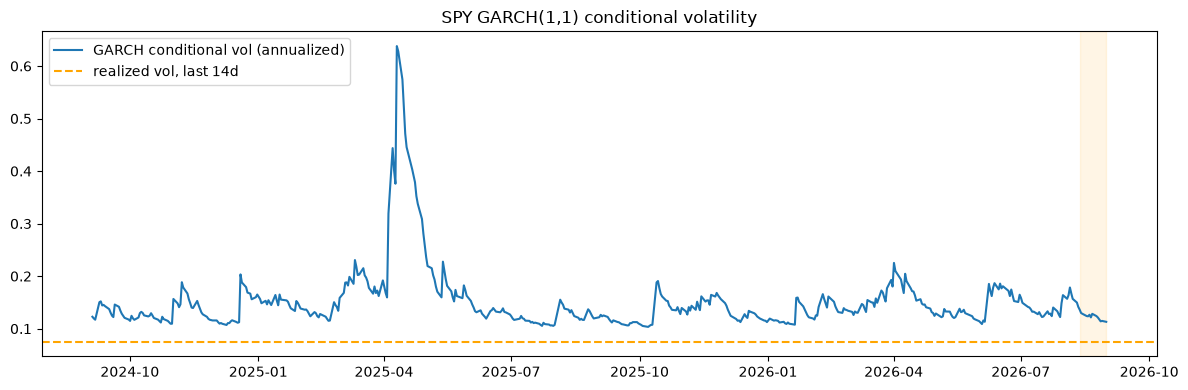

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(conditional_vol_annualized.index, conditional_vol_annualized.values, label="GARCH conditional vol (annualized)")
ax.axhline(annualized_vol_realized, color="orange", linestyle="--", label=f"realized vol, last {STATS_LOOKBACK_DAYS}d")
ax.axvspan(recent.index.min(), recent.index.max(), color="orange", alpha=0.1)
ax.set_title(f"{SYMBOL} GARCH(1,1) conditional volatility")
ax.legend()
plt.tight_layout()
plt.show()


---
## Block 3 — 0DTE option chain with Greeks

Looks for an expiration matching today's date. If today isn't a SPY expiration day, falls back to the nearest upcoming expiration and prints a warning so you know it's not actually 0DTE.


In [17]:
resp = c.get_option_chain(
    SYMBOL,
    contract_type=Client.Options.ContractType.ALL,
    strike_count=STRIKE_COUNT,
    include_underlying_quote=True,
)
assert resp.status_code == httpx.codes.OK, f"option chain request failed: {resp.status_code} {resp.text}"
chain = resp.json()

underlying_price = chain.get("underlyingPrice")
print(f"{SYMBOL} underlying price: {underlying_price}")

today_str = datetime.date.today().isoformat()

def flatten_exp_map(exp_map, option_type):
    rows = []
    for exp_key, strikes in exp_map.items():
        exp_date = exp_key.split(":")[0]
        for strike_str, contracts in strikes.items():
            for contract in contracts:
                rows.append({
                    "expiration": exp_date,
                    "option_type": option_type,
                    "strike": float(strike_str),
                    "bid": contract.get("bid"),
                    "ask": contract.get("ask"),
                    "last": contract.get("last"),
                    "volume": contract.get("totalVolume"),
                    "open_interest": contract.get("openInterest"),
                    "iv": contract.get("volatility"),
                    "delta": contract.get("delta"),
                    "gamma": contract.get("gamma"),
                    "theta": contract.get("theta"),
                    "vega": contract.get("vega"),
                    "rho": contract.get("rho"),
                })
    return rows

rows = flatten_exp_map(chain.get("callExpDateMap", {}), "CALL") + flatten_exp_map(chain.get("putExpDateMap", {}), "PUT")
chain_df = pd.DataFrame(rows)

available_expirations = sorted(chain_df["expiration"].unique())

if today_str in available_expirations:
    target_exp = today_str
    print(f"0DTE found: expiration {target_exp}")
else:
    future_exps = [e for e in available_expirations if e >= today_str]
    if not future_exps:
        raise RuntimeError("No expirations returned on/after today — widen STRIKE_COUNT or check the response.")
    target_exp = future_exps[0]
    print(f"No 0DTE today ({today_str}). Falling back to nearest expiration: {target_exp}")

chain_today = chain_df[chain_df["expiration"] == target_exp].copy()
chain_today = chain_today.sort_values(["option_type", "strike"]).reset_index(drop=True)
chain_today


SPY underlying price: 762.2
0DTE found: expiration 2026-09-01


,expiration,option_type,strike,bid,ask,last,volume,open_interest,iv,delta,gamma,theta,vega,rho
0,2026-09-01,CALL,753.0,8.32,9.63,9.04,35,100,21.368,1.000,0.000,-0.000,0.000,0.000
1,2026-09-01,CALL,754.0,8.15,8.39,8.38,175,287,20.406,1.000,0.000,-0.000,0.000,0.000
2,2026-09-01,CALL,755.0,7.17,7.38,7.19,339,405,19.043,0.959,0.008,-0.010,0.017,0.001
3,2026-09-01,CALL,756.0,6.19,6.41,6.33,447,225,18.001,0.951,0.019,-0.036,0.020,0.002
4,2026-09-01,CALL,757.0,5.29,5.33,5.37,695,227,16.937,0.935,0.033,-0.070,0.025,0.003
5,2026-09-01,CALL,758.0,4.34,4.38,4.40,1695,389,15.937,0.905,0.051,-0.120,0.034,0.003
6,2026-09-01,CALL,759.0,3.43,3.47,3.43,2102,375,15.171,0.853,0.075,-0.209,0.046,0.004
7,2026-09-01,CALL,760.0,2.58,2.61,2.58,7403,507,14.498,0.775,0.103,-0.357,0.061,0.004
8,2026-09-01,CALL,761.0,1.83,1.85,1.83,36407,499,13.910,0.666,0.130,-0.596,0.074,0.003
9,2026-09-01,CALL,762.0,1.19,1.20,1.19,88056,659,13.361,0.529,0.148,-0.956,0.080,0.003


In [18]:
# Near-the-money view: strikes within ~5% of the underlying price
if underlying_price:
    band = 0.05
    ntm = chain_today[chain_today["strike"].between(underlying_price * (1 - band), underlying_price * (1 + band))]
else:
    ntm = chain_today

cols = ["option_type", "strike", "bid", "ask", "last", "iv", "delta", "gamma", "theta", "vega", "rho", "volume", "open_interest"]
ntm[cols].style.format({
    "bid": "{:.2f}", "ask": "{:.2f}", "last": "{:.2f}",
    "iv": "{:.2%}", "delta": "{:.3f}", "gamma": "{:.4f}",
    "theta": "{:.3f}", "vega": "{:.3f}", "rho": "{:.3f}",
})


,option_type,strike,bid,ask,last,iv,delta,gamma,theta,vega,rho,volume,open_interest
0,CALL,753.000000,8.32,9.63,9.04,2136.80%,1.000,0.0000,-0.000,0.000,0.000,35,100
1,CALL,754.000000,8.15,8.39,8.38,2040.60%,1.000,0.0000,-0.000,0.000,0.000,175,287
2,CALL,755.000000,7.17,7.38,7.19,1904.30%,0.959,0.0080,-0.010,0.017,0.001,339,405
3,CALL,756.000000,6.19,6.41,6.33,1800.10%,0.951,0.0190,-0.036,0.020,0.002,447,225
4,CALL,757.000000,5.29,5.33,5.37,1693.70%,0.935,0.0330,-0.070,0.025,0.003,695,227
5,CALL,758.000000,4.34,4.38,4.40,1593.70%,0.905,0.0510,-0.120,0.034,0.003,1695,389
6,CALL,759.000000,3.43,3.47,3.43,1517.10%,0.853,0.0750,-0.209,0.046,0.004,2102,375
7,CALL,760.000000,2.58,2.61,2.58,1449.80%,0.775,0.1030,-0.357,0.061,0.004,7403,507
8,CALL,761.000000,1.83,1.85,1.83,1391.00%,0.666,0.1300,-0.596,0.074,0.003,36407,499
9,CALL,762.000000,1.19,1.20,1.19,1336.10%,0.529,0.1480,-0.956,0.080,0.003,88056,659


In [20]:
from scipy.stats import norm
import datetime

In [21]:
np.random.seed(1)
n = 504
dates = pd.date_range(end=pd.Timestamp.today(), periods=n, freq='B')
returns = np.random.normal(0.0003, 0.009, n)
# inject a few jumps
jump_idx = np.random.choice(n, 6, replace=False)
returns[jump_idx] += np.random.normal(0, 0.04, 6)
log_ret_all = pd.Series(returns, index=dates)

def calibrate_jump_diffusion(log_returns, jump_z_thresh=3.0):
    mu_all = log_returns.mean()
    sigma_all = log_returns.std()
    z = (log_returns - mu_all) / sigma_all
    is_jump = z.abs() > jump_z_thresh
    jump_rets = log_returns[is_jump]
    diffusive_rets = log_returns[~is_jump]
    lam_daily = is_jump.sum() / len(log_returns)
    jump_mean = jump_rets.mean() if len(jump_rets) else 0.0
    jump_std = jump_rets.std() if len(jump_rets) > 1 else 0.0
    sigma_daily = diffusive_rets.std()
    return {
        "mu_daily": diffusive_rets.mean(),
        "sigma_daily": sigma_daily,
        "lam_daily": lam_daily,
        "jump_mean": jump_mean,
        "jump_std": jump_std,
        "n_jumps_observed": int(is_jump.sum()),
    }

jd_params = calibrate_jump_diffusion(log_ret_all)
print("jd_params", jd_params)

MINUTES_PER_DAY = 390
TRADING_DAYS_PER_YEAR = 252
MINUTES_PER_YEAR = MINUTES_PER_DAY * TRADING_DAYS_PER_YEAR
DT_MIN = 1

def simulate_jump_diffusion(S0, minutes_to_horizon, jd_params, obi_signal=0.0, obi_sensitivity=0.15, n_paths=20000, dt_min=DT_MIN, seed=None):
    rng = np.random.default_rng(seed)
    n_steps = max(int(minutes_to_horizon / dt_min), 1)
    dt = dt_min / MINUTES_PER_YEAR

    mu_annual = jd_params["mu_daily"] * TRADING_DAYS_PER_YEAR
    sigma_annual = jd_params["sigma_daily"] * np.sqrt(TRADING_DAYS_PER_YEAR)
    lam_annual = jd_params["lam_daily"] * TRADING_DAYS_PER_YEAR
    jump_mean = jd_params["jump_mean"]
    jump_std = jd_params["jump_std"]

    mu_annual_tilted = mu_annual + obi_sensitivity * obi_signal
    jump_comp = lam_annual * (np.exp(jump_mean + 0.5 * jump_std ** 2) - 1)
    drift = mu_annual_tilted - 0.5 * sigma_annual ** 2 - jump_comp

    log_paths = np.full(n_paths, np.log(S0))
    for _ in range(n_steps):
        z = rng.standard_normal(n_paths)
        diffusion = drift * dt + sigma_annual * np.sqrt(dt) * z
        n_jumps = rng.poisson(lam_annual * dt, n_paths)
        jump_sizes = np.zeros(n_paths)
        jumpers = n_jumps > 0
        if jumpers.any():
            jump_sizes[jumpers] = rng.normal(jump_mean * n_jumps[jumpers], jump_std * np.sqrt(n_jumps[jumpers]))
        log_paths += diffusion + jump_sizes
    return np.exp(log_paths)

S0 = 560.0
noon_prices = simulate_jump_diffusion(S0, 90, jd_params, obi_signal=0.2, seed=1)
close_prices = simulate_jump_diffusion(S0, 240, jd_params, obi_signal=0.2, seed=2)
print("noon mean/std", noon_prices.mean(), noon_prices.std())
print("close mean/std", close_prices.mean(), close_prices.std())

def bs_price_greeks(S, K, tau_years, sigma, option_type, r=0.05):
    S = np.asarray(S, dtype=float)
    if tau_years <= 0 or sigma <= 0:
        if option_type == "CALL":
            price = np.maximum(S - K, 0.0)
        else:
            price = np.maximum(K - S, 0.0)
        return {"price": price, "theta": np.zeros_like(S)}
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * tau_years) / (sigma * np.sqrt(tau_years))
    d2 = d1 - sigma * np.sqrt(tau_years)
    if option_type == "CALL":
        price = S * norm.cdf(d1) - K * np.exp(-r * tau_years) * norm.cdf(d2)
        theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(tau_years)) - r * K * np.exp(-r * tau_years) * norm.cdf(d2)) / 365
    else:
        price = K * np.exp(-r * tau_years) * norm.cdf(-d2) - S * norm.cdf(-d1)
        theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(tau_years)) + r * K * np.exp(-r * tau_years) * norm.cdf(-d2)) / 365
    return {"price": price, "theta": theta}

positions = pd.DataFrame([
    {"strike": 555, "option_type": "CALL", "bid": 6.0, "ask": 6.2, "iv": 0.13, "direction": "long"},
    {"strike": 560, "option_type": "CALL", "bid": 2.5, "ask": 2.7, "iv": 0.13, "direction": "short"},
    {"strike": 565, "option_type": "PUT",  "bid": 5.5, "ask": 5.7, "iv": 0.14, "direction": "long"},
])
positions["entry_price"] = (positions["bid"] + positions["ask"]) / 2

now = datetime.datetime.now()
noon_dt = now.replace(hour=12, minute=0, second=0, microsecond=0)
close_dt = now.replace(hour=16, minute=0, second=0, microsecond=0)
def minutes_remaining(target, now=None):
    now = now or datetime.datetime.now()
    return max((target - now).total_seconds()/60.0, 0.0)
tau_noon = minutes_remaining(noon_dt)/MINUTES_PER_YEAR
tau_close = minutes_remaining(close_dt)/MINUTES_PER_YEAR

CONTRACT_MULTIPLIER = 100
results = []
for _, row in positions.iterrows():
    sign = 1 if row["direction"] == "long" else -1
    iv = row["iv"]
    theta_noon = bs_price_greeks(S0, row["strike"], tau_noon, iv, row["option_type"])
    theta_close = bs_price_greeks(S0, row["strike"], tau_close, iv, row["option_type"])
    pnl_theta_noon = sign*(theta_noon["price"] - row["entry_price"])*CONTRACT_MULTIPLIER
    pnl_theta_close = sign*(theta_close["price"] - row["entry_price"])*CONTRACT_MULTIPLIER

    noon_vals = bs_price_greeks(noon_prices, row["strike"], tau_noon, iv, row["option_type"])["price"]
    close_vals = bs_price_greeks(close_prices, row["strike"], tau_close, iv, row["option_type"])["price"]
    pnl_noon_mc = sign*(noon_vals - row["entry_price"])*CONTRACT_MULTIPLIER
    pnl_close_mc = sign*(close_vals - row["entry_price"])*CONTRACT_MULTIPLIER

    results.append({
        "strike": row["strike"], "type": row["option_type"], "dir": row["direction"],
        "entry": row["entry_price"],
        "pnl_theta_noon": float(pnl_theta_noon), "pnl_theta_close": float(pnl_theta_close),
        "exp_pnl_noon": pnl_noon_mc.mean(), "exp_pnl_close": pnl_close_mc.mean(),
        "pop_noon": (pnl_noon_mc>0).mean(), "pop_close": (pnl_close_mc>0).mean(),
    })

df = pd.DataFrame(results)
print(df)
print("ALL OK")

jd_params {'mu_daily': np.float64(0.0007265732394381358), 'sigma_daily': np.float64(0.008844248708057008), 'lam_daily': np.float64(0.007936507936507936), 'jump_mean': np.float64(0.02968052364741722), 'jump_std': np.float64(0.0445769245556107), 'n_jumps_observed': 4}
noon mean/std 560.1390021526304 2.8324151571667593
close mean/std 560.3515047498881 4.522951459232959
   strike  type    dir  entry  pnl_theta_noon  pnl_theta_close  exp_pnl_noon  \
0     555  CALL   long    6.1     -105.532879       -75.403290    -83.546001   
1     560  CALL  short    2.6      163.162519        82.751056    114.283814   
2     565   PUT   long    5.6      -60.350525       -34.526528    -59.273560   

   exp_pnl_close  pop_noon  pop_close  
0      -8.882398   0.34435    0.43870  
1      -0.539213   0.82820    0.61955  
2     -17.095743   0.38525    0.43495  
ALL OK
